# Data Generation

In [65]:
%matplotlib inline
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

dim_theta = 10
data_num = 1000
scale = .1

theta_true = np.ones((dim_theta,1))
print('True theta:', theta_true.reshape(-1))

A = np.random.uniform(low=-1.0, high=1.0, size=(data_num,dim_theta))
y_data = A @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(data_num, 1))

A_test = np.random.uniform(low=-1.0, high=1.0, size=(50, dim_theta))
y_test = A_test @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(50, 1))

True theta: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Solving for the exact mean squared loss (solving Ax = b)

In [66]:
'''
Hints:
1. See the least squares solution to Ax = b (when it is covered in lecture).

2. Use Numpy functions like Numpy's linear algebra functions to solve for x in Ax = b.
In fact, the linear algebra module is already imported with ```import numpy.linalg as la```.

3. Use the defined variable A in Ax = b. Use y_data as b. Use theta_pred as x.
'''

"""
The least squares closed form is (A^T A)^-1 A^T b
"""

theta_pred = la.inv(A.T @ A) @ A.T @ y_data

print('Empirical theta', theta_pred.flatten())

Empirical theta [0.99858424 0.99607218 1.00281587 0.99940389 1.00158489 0.99564827
 1.00056117 0.9955768  0.9976992  0.9857047 ]


# SGD Variants Noisy Function

In [105]:
batch_size = 1
max_iter = 1000
lr = 0.001
theta_init = np.random.random((10,1)) * 0.1

In [106]:
def noisy_val_grad(theta_hat, data_, label_, deg_=2.):
    gradient = np.zeros_like(theta_hat)
    loss = 0
    for i in range(data_.shape[0]):
        x_ = data_[i, :].reshape(-1,1)
        y_ = label_[i, 0]
        err = np.sum(x_ * theta_hat) - y_

        '''
        Hints:
        1. Find the gradient and loss for each data point x_.
        2. For grad, you need err, deg_, and x_.
        3. For l, you need err and deg_ only.
        4. Checkout the writeup for more hints.
        '''

        # derivative of Q wrt theta is gamma |error| ^ (gamma - 1) * derivative(|error|)
        # with derivative(|error|) = sign(error)
        
        grad = deg_ * (np.abs(err)**(deg_ - 1)) * np.sign(err) * x_
        
        l = np.abs(err)**(deg_)
        
        # print("ds", data_.shape[0])
        loss += l / data_.shape[0]
        gradient += grad / data_.shape[0]
        
    return loss, gradient

# Running SGD Variants

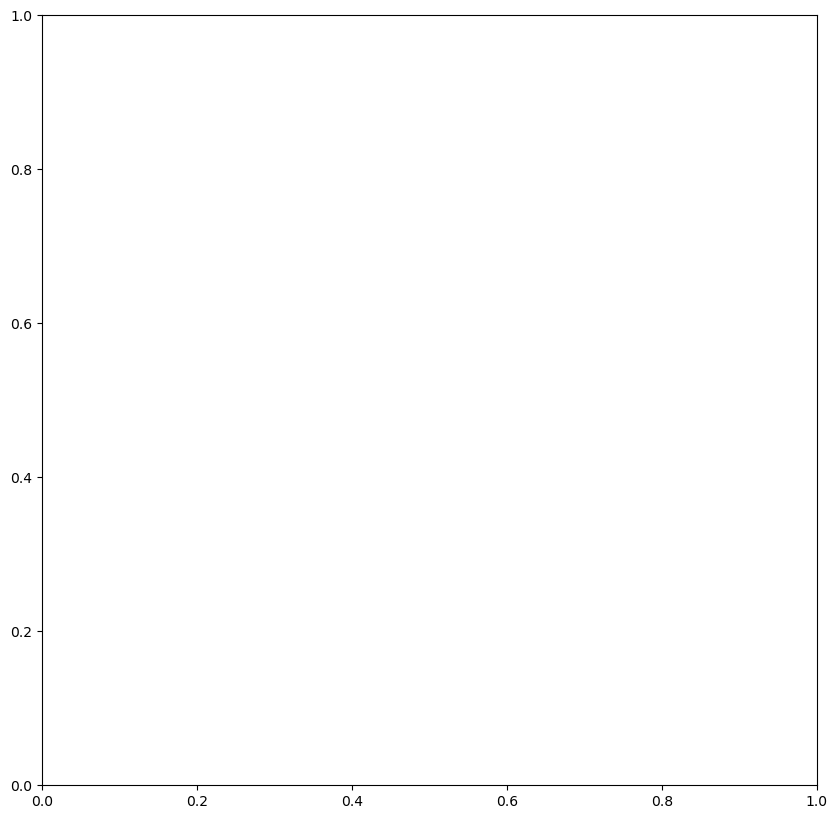

In [119]:
#@title Parameters
deg_ = 2. #@param {type: "number"}
num_rep = 10 #@param {type: "integer"}
max_iter = 1000 #@param {type: "integer"}
fig, ax = plt.subplots(figsize=(10,10))
best_vals = {}
test_exp_interval = 50 #@param {type: "integer"}
grad_artificial_normal_noise_scale = 0. #@param {type: "number"}

Final averaged parameters for adam:
[0.3046, 0.3296, 0.3156, 0.3145, 0.3268, 0.3235, 0.3143, 0.3182, 0.3270, 0.3165]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.4958, 0.5050, 0.5093, 0.5304, 0.4941, 0.5348, 0.5131, 0.5169, 0.5038, 0.5089]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


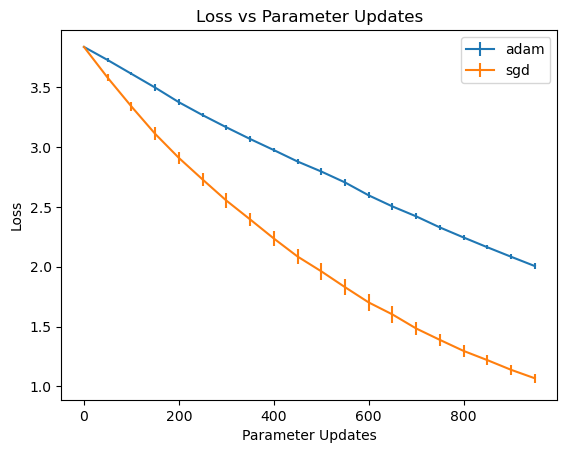

In [ ]:
# for method_idx, method in enumerate(['adam', 'sgd', 'adagrad']):
for method_idx, method in enumerate(['adam', 'sgd']):
    test_loss_mat = []
    train_loss_mat = []

    final_thetas = []
    
    for replicate in range(num_rep):
        if method == 'adam':
            beta_1 = 0.9
            beta_2 = 0.999
            m = np.zeros((dim_theta, 1)) # TODO: Initialize parameters
            v = np.zeros((dim_theta, 1))
            epsilon = 1e-8
            # alpha is the learning rate, which is defined as lr above

        if method == 'adagrad':
            print('Adagrad Not implemented.')
            epsilon = 1e-8 # TODO: Initialize parameters
            squared_sum = NotImplemented
            
        theta_hat = theta_init.copy()
        test_loss_list = []
        train_loss_list = []

        for t in range(max_iter):
            idx = np.random.choice(data_num, batch_size) # Split data
            train_loss, gradient = noisy_val_grad(theta_hat, A[idx,:], y_data[idx,:], deg_=deg_)
            artificial_grad_noise = np.random.randn(10, 1) * grad_artificial_normal_noise_scale + np.sign(np.random.random((10, 1)) - 0.5) * 0.
            gradient = gradient + artificial_grad_noise
            train_loss_list.append(train_loss)
            
            if t % test_exp_interval == 0:
                test_loss, _ = noisy_val_grad(theta_hat, A_test[:,:], y_test[:,:], deg_=deg_)
                test_loss_list.append(test_loss)                
            
            if method == 'adam':
                m = beta_1 * m + (1 - beta_1) * gradient
                v = beta_2 * v + (1 - beta_2) * (gradient ** 2)
                m_hat = m / (1 - beta_1 ** (t + 1))
                v_hat = v / (1 - beta_2 ** (t + 1))
                theta_hat = theta_hat - (lr * m_hat / (np.sqrt(v_hat) + epsilon))
            
            elif method == 'adagrad':
                print('Adagrad Not implemented.')
                squared_sum = squared_sum + NotImplemented # TODO: Implement Adagrad
                theta_hat = theta_hat - lr * NotImplemented
            
            elif method == 'sgd':
                theta_hat = theta_hat - lr * gradient
        
        
        final_thetas.append(theta_hat.flatten())

        test_loss_mat.append(test_loss_list)
        train_loss_mat.append(train_loss_list)

    print(f"Final averaged parameters for {method}:")
    print("[" + ", ".join([f"{x:.4f}" for x in np.mean(final_thetas, axis=1)]) +"]")
    

    x_axis = np.arange(max_iter)[::test_exp_interval]
    
    print('test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training')
    print('The elements of test_loss_np are the test loss values computed in each replicate and training stage.')
    test_loss_np = np.array(test_loss_mat)
    
    '''
    Hints:
    1. Use test_loss_np in np.mean() with axis = 0
    '''
    test_loss_mean = np.mean(test_loss_np, axis=0)

    '''
    Hints:
    1. Use test_loss_np in np.std() with axis = 0 
    2. Divide by np.sqrt() using num_rep as a parameter
    '''
    test_loss_se = np.std(test_loss_np, axis=0) / np.sqrt(num_rep)

    plt.errorbar(x_axis, test_loss_mean, yerr=2.5*test_loss_se, label=method)
    best_vals[method] = min(test_loss_mean)

plt.legend()
plt.ylabel("Loss")
plt.xlabel("Parameter Updates")
plt.title("Loss vs Parameter Updates")
plt.show()

/var/folders/p0/dk7rn_p13696d5kc3rkzjfdh0000gn/T/ipykernel_1175/2927815680.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Updates')

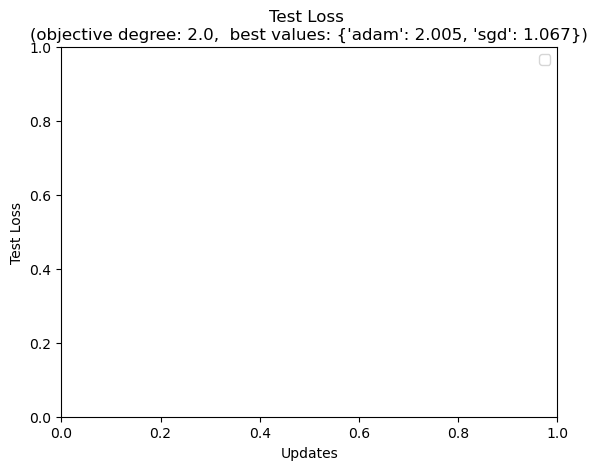

In [121]:
best_vals = { k: int(v * 1000) / 1000. for k,v in best_vals.items() } # A weird way to round numbers
plt.title(f'Test Loss \n(objective degree: {deg_},  best values: {best_vals})')
plt.ylabel('Test Loss')
plt.legend()
plt.xlabel('Updates')

Final averaged parameters for adam:
[0.1346, 0.1312, 0.0997, 0.1197, 0.1430, 0.1161, 0.1134, 0.1230, 0.0894, 0.1080]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.0841, 0.0853, 0.0840, 0.0845, 0.0837, 0.0839, 0.0837, 0.0835, 0.0839, 0.0836]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


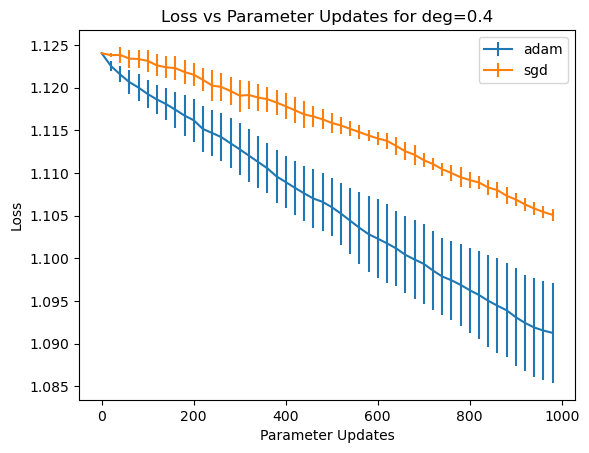

Final averaged parameters for adam:
[0.2083, 0.2196, 0.2329, 0.2165, 0.2121, 0.2228, 0.2377, 0.2218, 0.2300, 0.2198]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.1252, 0.1282, 0.1271, 0.1254, 0.1271, 0.1251, 0.1277, 0.1240, 0.1270, 0.1276]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


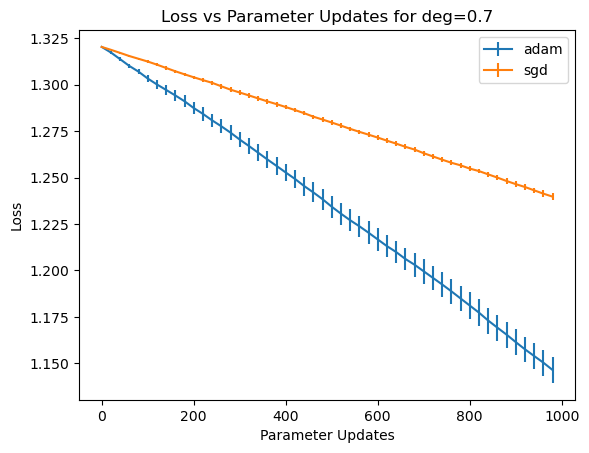

Final averaged parameters for adam:
[0.2941, 0.2863, 0.2994, 0.2911, 0.2931, 0.2925, 0.2907, 0.2787, 0.2824, 0.2841]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.1849, 0.1797, 0.1850, 0.1860, 0.1887, 0.1878, 0.1863, 0.1814, 0.1896, 0.1857]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


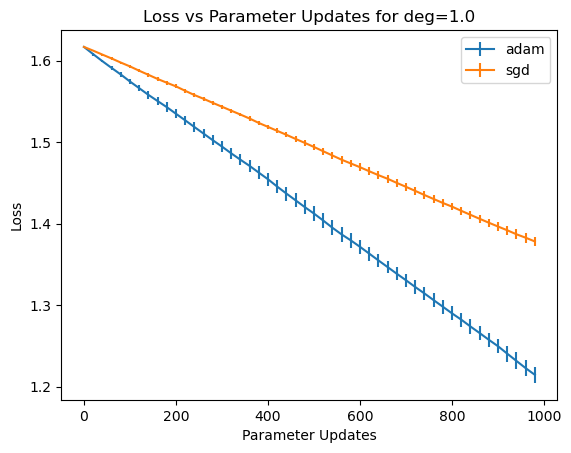

Final averaged parameters for adam:
[0.3114, 0.3207, 0.3234, 0.3291, 0.3175, 0.3218, 0.3166, 0.3276, 0.3283, 0.3224]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.5150, 0.5172, 0.5101, 0.4823, 0.4916, 0.5018, 0.5146, 0.5298, 0.4988, 0.5154]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


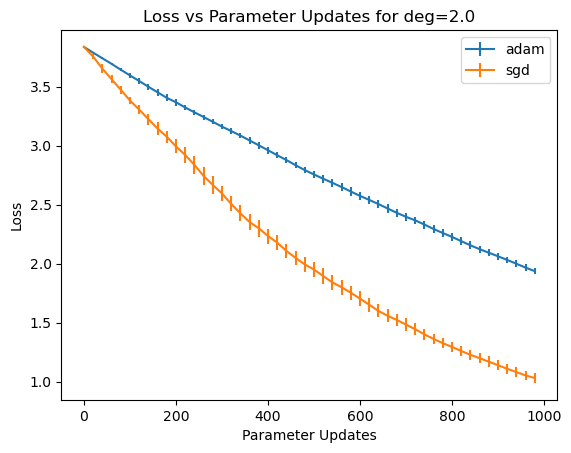

Final averaged parameters for adam:
[0.2805, 0.2772, 0.2671, 0.2791, 0.2692, 0.2762, 0.2757, 0.2874, 0.2758, 0.2827]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.7545, 0.7447, 0.7449, 0.7223, 0.7686, 0.7519, 0.7340, 0.7489, 0.7423, 0.7646]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


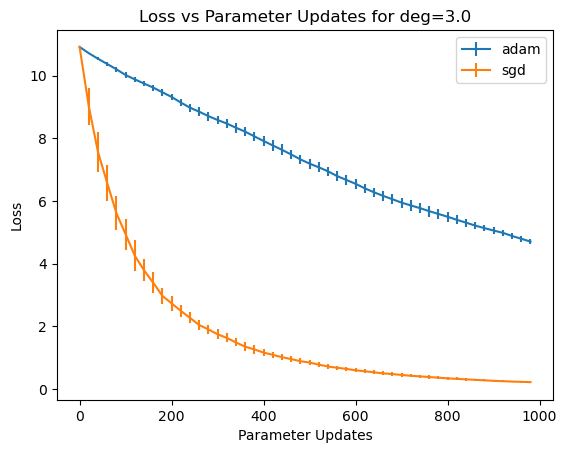

Final averaged parameters for adam:
[0.2202, 0.2057, 0.2489, 0.2383, 0.1790, 0.2131, 0.2184, 0.2168, 0.2085, 0.2007]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.8652, 0.8444, 0.8902, 0.8701, 0.8539, 0.8622, 1.0211, 0.8503, 0.8584, 0.9069]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


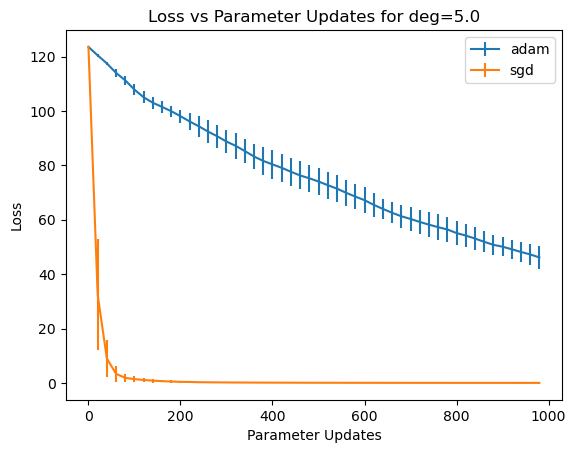

Final averaged parameters for adam:
[0.3241, 0.3306, 0.3295, 0.3266, 0.3369, 0.3143, 0.3198, 0.3134, 0.3262, 0.3300]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.
Final averaged parameters for sgd:
[0.3371, 0.3225, 0.3284, 0.3433, 0.3219, 0.3312, 0.3323, 0.3221, 0.3222, 0.3172]
test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training
The elements of test_loss_np are the test loss values computed in each replicate and training stage.


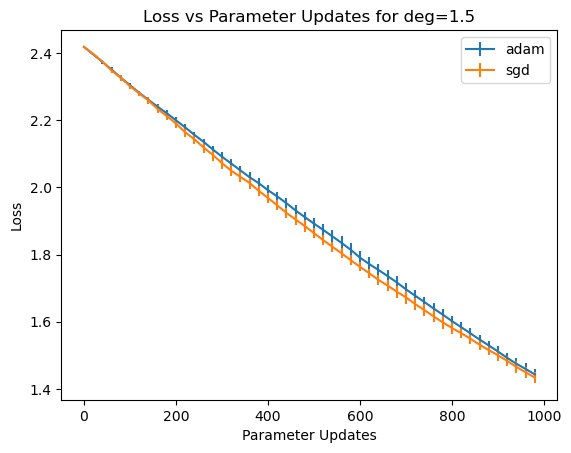

In [130]:
for deg_ in [0.4, 0.7, 1., 2., 3., 5., 1.5]:
    for method_idx, method in enumerate(['adam', 'sgd']):
        test_loss_mat = []
        train_loss_mat = []

        final_thetas = []
        
        for replicate in range(num_rep):
            if method == 'adam':
                beta_1 = 0.9
                beta_2 = 0.999
                m = np.zeros((dim_theta, 1)) # TODO: Initialize parameters
                v = np.zeros((dim_theta, 1))
                epsilon = 1e-8
                # alpha is the learning rate, which is defined as lr above

            if method == 'adagrad':
                print('Adagrad Not implemented.')
                epsilon = 1e-8 # TODO: Initialize parameters
                squared_sum = NotImplemented
                
            theta_hat = theta_init.copy()
            test_loss_list = []
            train_loss_list = []

            for t in range(max_iter):
                idx = np.random.choice(data_num, batch_size) # Split data
                train_loss, gradient = noisy_val_grad(theta_hat, A[idx,:], y_data[idx,:], deg_=deg_)
                artificial_grad_noise = np.random.randn(10, 1) * grad_artificial_normal_noise_scale + np.sign(np.random.random((10, 1)) - 0.5) * 0.
                gradient = gradient + artificial_grad_noise
                train_loss_list.append(train_loss)
                
                if t % test_exp_interval == 0:
                    test_loss, _ = noisy_val_grad(theta_hat, A_test[:,:], y_test[:,:], deg_=deg_)
                    test_loss_list.append(test_loss)                
                
                if method == 'adam':
                    m = beta_1 * m + (1 - beta_1) * gradient
                    v = beta_2 * v + (1 - beta_2) * (gradient ** 2)
                    m_hat = m / (1 - beta_1 ** (t + 1))
                    v_hat = v / (1 - beta_2 ** (t + 1))
                    theta_hat = theta_hat - (lr * m_hat / (np.sqrt(v_hat) + epsilon))
                
                elif method == 'adagrad':
                    print('Adagrad Not implemented.')
                    squared_sum = squared_sum + NotImplemented # TODO: Implement Adagrad
                    theta_hat = theta_hat - lr * NotImplemented
                
                elif method == 'sgd':
                    theta_hat = theta_hat - lr * gradient
            
            
            final_thetas.append(theta_hat.flatten())

            test_loss_mat.append(test_loss_list)
            train_loss_mat.append(train_loss_list)

        print(f"Final averaged parameters for {method}:")
        print("[" + ", ".join([f"{x:.4f}" for x in np.mean(final_thetas, axis=1)]) +"]")
        

        x_axis = np.arange(max_iter)[::test_exp_interval]
        
        print('test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training')
        print('The elements of test_loss_np are the test loss values computed in each replicate and training stage.')
        test_loss_np = np.array(test_loss_mat)
        
        '''
        Hints:
        1. Use test_loss_np in np.mean() with axis = 0
        '''
        test_loss_mean = np.mean(test_loss_np, axis=0)

        '''
        Hints:
        1. Use test_loss_np in np.std() with axis = 0 
        2. Divide by np.sqrt() using num_rep as a parameter
        '''
        test_loss_se = np.std(test_loss_np, axis=0) / np.sqrt(num_rep)

        plt.errorbar(x_axis, test_loss_mean, yerr=2.5*test_loss_se, label=method)
        best_vals[method] = min(test_loss_mean)

    plt.legend()
    plt.ylabel("Loss")
    plt.xlabel("Parameter Updates")
    plt.title(f"Loss vs Parameter Updates for deg={deg_}")
    plt.show()